# Market Facilitation Index — a quantitative teardown 🔬
### The 4-state classifier · continuation-score Welch/placebo splits · pooled & per-ticker replication · a NET timer race with HAC *t* · a 20-seed synthetic positive control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Green/Squat?: Busted](https://img.shields.io/badge/Green%2FSquat%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). Bill Williams' BW-MFI names four bar "colors" from the cross of two bar-to-bar sign changes — MFI's own direction, volume's own direction — and claims Green predicts continuation, Squat predicts reversal. Neither claim has a peer-reviewed anchor; this is a direct, first-principles test.

> ⚠️ **Data note.** SPY + 5-ETF basket (QQQ, DIA, IWM, XLE, GLD), RAW daily OHLCV for the BW-MFI ratio, adjusted close for every return, 1993-02-01 → 2026-06-30. No survivorship — every tape is a single continuously-traded ETF. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md) (fingerprint `77c7e57287b6` for SPY).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from market_facilitation_index import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    BASKET = data.load_basket()
    SPY_BARS = BASKET["SPY"]
    DF = st.day_frame(SPY_BARS)
else:
    BASKET = SPY_BARS = DF = None
print("real cache present:", HAVE_REAL, "| tickers:", data.TICKERS,
      "| SPY bars:", (0 if DF is None else len(DF)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '1993-02-01', 'end': '2026-06-30', 'tickers': ['SPY', 'QQQ', 'DIA', 'IWM', 'XLE', 'GLD'], 'fp_spy': '77c7e57287b6', 'fp_qqq': 'f8a90001e6b4', 'fp_dia': '2b099f19b356', 'fp_iwm': 'c02ce892c294', 'fp_xle': 'fca8869d5f64', 'fp_gld': 'e20ec7413593', 'n_spy': 8410, 'n_classified': 8409, 'spy': {'green': (1954, 6.64, 4.19, 0.84, -4.29, -1.8, -0.85, 46.5), 'fade': (2002, 3.68, 5.1, -0.48, 2.35, -3.86, 2.08, 49.6), 'fake': (2256, 6.76, 4.02, 0.94, -6.07, -1.02, -1.74, 49.1), 'squat': (2196, 2.01, 5.73, -1.26, -1.19, -2.8, 0.54, 48.6)}, 'placebo_green_gap': -2.48, 'placebo_green_p': 0.4008, 'placebo_squat_gap': 1.6, 'placebo_squat_p': 0.5842, 'pooled': {'green': (8864, 5.56, 0.63, -3.03, -0.33, 48.5), 'fade': (9218, 5.43, 0.54, -1.16, 1.1, 48.8), 'fake': (11894, 6.83, 1.89, -4.88, -2.07, 49.2), 'squat': (11364, 1.32, -2.89, -1.0, 1.35, 48.3)}, 'per_ticker': {'SPY': (-0.85, 1954, 0.54, 2196), 'QQQ': (-0.37, 1699, 1.31, 1680), 'DIA': (-0.02, 1432, 0.92, 2057), 'IWM': (0.21, 1396, -0.13, 1800), 'XLE': (0.02, 1234, 0.58, 2168), 'GLD': (0.39, 1149, -0.23, 1463)}, 'timer': {'green': (0.33, 0.65, -3.63, -3.55, 52.0), 'squat_avoid': (0.61, 0.65, -0.966, -1.53, 55.5), 'sma': (0.75, 0.65, -0.719, -0.97, 0.5)}, 'cost_sweep': [(0.0, 0.45, -3.14), (1.0, 0.33, -3.55), (2.0, 0.21, -3.95), (5.0, -0.15, -5.17)], 'perm_gap': -0.314, 'perm_p': 0.211, 'syn_null_green_mean': 0.35, 'syn_null_green_sd': 0.87, 'syn_null_green_fire': 1, 'syn_null_squat_mean': -0.17, 'syn_null_squat_sd': 0.76, 'syn_null_squat_fire': 0, 'syn_planted_green_bps': 70.42, 'syn_planted_green_t': 17.23, 'syn_planted_squat_bps': -63.65, 'syn_planted_squat_t': -22.14}


real cache present: True | tickers: ['SPY', 'QQQ', 'DIA', 'IWM', 'XLE', 'GLD'] | SPY bars: 8410


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Green cont-score Welch **t = -0.85** (SPY), **t = -0.33** (pooled 6 tickers, n=8,864); Squat **t = 0.54** (SPY), **t = 1.35** (pooled); placebo *p* = 0.40 / 0.58 |
| **Tradability** | `MIRAGE` | Green-filter timer HAC **t = -3.55** vs buy-hold, net Sharpe 0.33 vs 0.65, still significant at 0 bp cost |
| **Green/Squat claim?** | `BUSTED` | wrong sign on the headline tape, no consistent sign across 6 tickers, placebo confirms noise |

> 💡 In plain words: a plausible-sounding volume-confirmation rule that simply isn't in the data, on either side of its own claim.

## 1 · The claim, steelmanned

Let $\text{MFI}_t = (H_t - L_t)/V_t$. Define
$\text{state}(t) \in \{\text{green, fade, fake, squat}\}$ from $\text{sign}(\Delta\text{MFI}_t) \times \text{sign}(\Delta V_t)$: green = (+,+), fade = (−,−), fake = (+,−), squat = (−,+). Let $r_t$ be day $t$'s return and $\text{fwd}_t = r_{t+1}$. The **continuation score** is $c_t = \text{sign}(r_t) \cdot \text{fwd}_t$.

- **H₁ (Green continuation).** $E[c_t \mid \text{state}(t)=\text{green}] > 0$, and above the unconditional mean.
- **H₂ (Squat reversal).** $E[c_t \mid \text{state}(t)=\text{squat}] < 0$, and below the unconditional mean.
- **H₃ (replication).** The sign of H₁/H₂ should hold across independent tickers — a categorical claim this simple has no excuse to be instrument-specific.
- **H₄ (capture).** A Green-only long/flat timer, net of costs, should beat buy-and-hold.

We find **H₁ rejected** (wrong sign, *t* = −0.85 SPY / −0.33 pooled), **H₂ rejected** (wrong sign, *t* = +0.54 SPY / +1.35 pooled), **H₃ rejected** (sign flips 3-of-6 tickers for both states) and **H₄ rejected** in the strongest possible way — the timer loses *significantly*.

## 2 · So what? — inference design

The continuation score at consecutive days overlaps by one observation (day *t*'s fwd return is day *t+1*'s own return), so within-state serial dependence is mild but present; the **Welch t** on the group split is the planned primary, and every conditional mean carries a **2,000-draw label-shuffle placebo** — reassign the state label to a random same-size subset of days, holding every continuation score fixed, so the null distribution reflects the study's own sample, not a textbook formula. The timer's daily return difference against buy-and-hold gets a **Newey-West HAC** *t* (returns are autocorrelated) plus its own **sign-permutation** placebo. Pooling across six tickers and reporting the per-ticker split separately guards against a categorical claim laundering a single lucky instrument into six-fold "confirmation."

## 3 · How we'd know — the protocol

- **Tape.** SPY + 5-ETF basket, RAW OHLCV 1993-02-01 → 2026-06-30 (as-of, last complete month). No survivorship (single continuously-traded ETFs).
- **Classifier.** `state(t)` from bar-to-bar MFI/Volume sign crosses — known at close *t*, needs only that bar and the one before.
- **Headline.** Welch *t* (forward return + continuation score) per state vs all other days, plus the label-shuffle placebo.
- **Replication.** Pooled 6-ticker version, then a per-ticker sign check.
- **Execution.** One lag: color known at close *t* earns the return of *t+1* (`fwd_ret`) or the timer position applied with one `shift`.
- **Timer.** Green filter + Squat avoidance + an SMA(50/200) benchmark, NET of one-way costs × NAV per flip, HAC *t* vs buy-and-hold, cost sweep, sign-permutation placebo.
- **Control.** Synthetic tape, range/volume independent of the return path, TUNABLE planted Green-continuation/Squat-reversal knob; the null must not fire across 20 seeds.

## 4 · The teardown

### 4a · The headline split and its placebo (SPY)

Forward return and continuation score by state, Welch *t* vs all other days.

green  n= 1954  fwd= +6.64bps t=+0.84   cont= -4.29bps t=-0.85
fade   n= 2002  fwd= +3.68bps t=-0.48   cont= +2.35bps t=+2.08
fake   n= 2256  fwd= +6.76bps t=+0.94   cont= -6.07bps t=-1.74
squat  n= 2196  fwd= +2.01bps t=-1.26   cont= -1.19bps t=+0.54


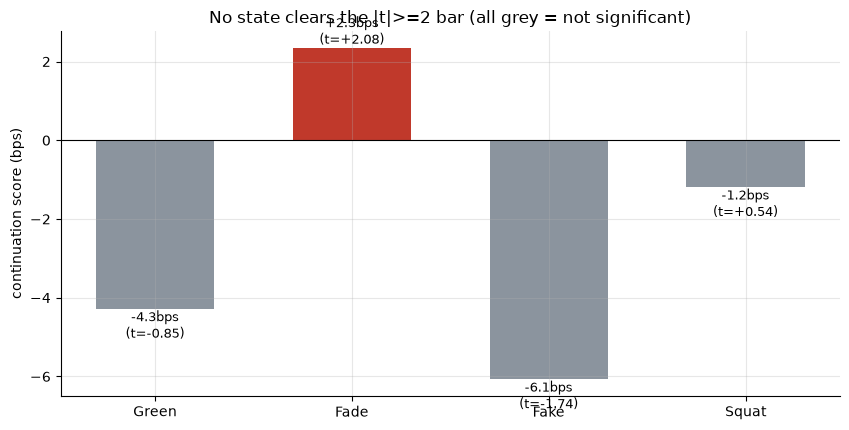

In [2]:
if HAVE_REAL:
    s = st.state_stats(DF)
else:
    s = {k: dict(zip(['n','fwd_bps','rest_fwd_bps','welch_t_fwd','cont_bps',
                      'rest_cont_bps','welch_t_cont','cont_hit'],
                     list(v[:7]) + [v[7]/100]))
         for k, v in R['spy'].items()}
for k in ['green', 'fade', 'fake', 'squat']:
    v = s[k]
    print(f"{k:6s} n={v['n']:5d}  fwd={v['fwd_bps']:+6.2f}bps t={v['welch_t_fwd']:+5.2f}   cont={v['cont_bps']:+6.2f}bps t={v['welch_t_cont']:+5.2f}")
fig, ax = plt.subplots(figsize=(8.6, 4.4))
labels = ['Green', 'Fade', 'Fake', 'Squat']
conts = [s[x]['cont_bps'] for x in ['green', 'fade', 'fake', 'squat']]
ts = [s[x]['welch_t_cont'] for x in ['green', 'fade', 'fake', 'squat']]
cols = [RED if abs(t) >= 2 else GREY for t in ts]
ax.bar(labels, conts, color=cols, width=.6)
for i, (v, t) in enumerate(zip(conts, ts)):
    ax.annotate(f'{v:+.1f}bps\n(t={t:+.2f})', (i, v), ha='center',
                va='top' if v < 0 else 'bottom', fontsize=9)
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('continuation score (bps)')
ax.set_title('No state clears the |t|>=2 bar (all grey = not significant)')
plt.tight_layout(); plt.show()

> 💡 In plain words: Green's continuation score is **-4.29 bps** at *t* = **-0.85** — negative, the wrong sign, and nowhere near significant. Squat's is **-1.19 bps** at *t* = **+0.54** — also not significant. The label-shuffle placebo (2,000 draws) puts Green's gap at *p* = **0.4008** and Squat's at *p* = **0.5842** — both squarely inside a random-relabeling null.

### 4b · Pooled across the basket and the per-ticker replication check

Six tickers pooled (~50k state-days), then split back out to see whether the *sign* is even stable.

pooled green: n=8,864 cont=-3.03bps t=-0.33
pooled squat: n=11,364 cont=-1.00bps t=+1.35


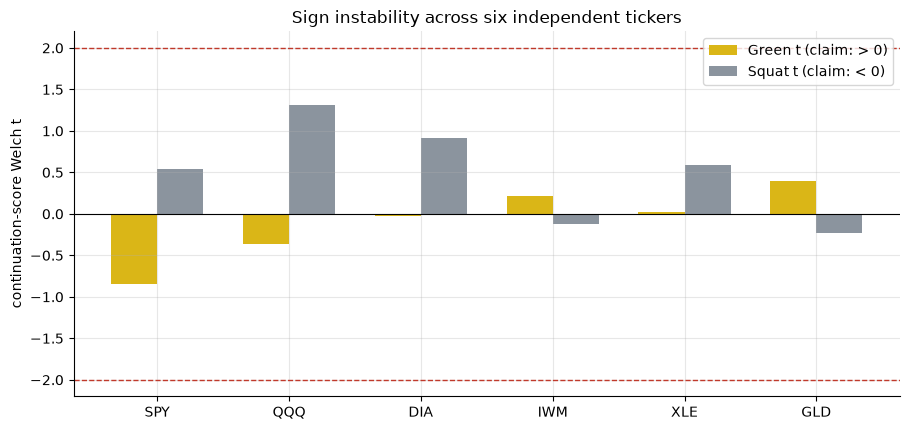

In [3]:
if HAVE_REAL:
    pooled = st.pooled_frame(BASKET)
    sp = st.state_stats(pooled)
    tickers = list(BASKET.keys())
    gts = [st.state_stats(st.day_frame(BASKET[t]))['green']['welch_t_cont'] for t in tickers]
    sts = [st.state_stats(st.day_frame(BASKET[t]))['squat']['welch_t_cont'] for t in tickers]
else:
    sp = {k: dict(zip(['n','fwd_bps','welch_t_fwd','cont_bps','welch_t_cont','cont_hit'], v))
          for k, v in R['pooled'].items()}
    tickers = list(R['per_ticker'].keys())
    gts = [R['per_ticker'][t][0] for t in tickers]
    sts = [R['per_ticker'][t][2] for t in tickers]
print(f"pooled green: n={sp['green']['n']:,} cont={sp['green']['cont_bps']:+.2f}bps "
      f"t={sp['green']['welch_t_cont']:+.2f}")
print(f"pooled squat: n={sp['squat']['n']:,} cont={sp['squat']['cont_bps']:+.2f}bps "
      f"t={sp['squat']['welch_t_cont']:+.2f}")
fig, ax = plt.subplots(figsize=(9.2, 4.4))
x = np.arange(len(tickers)); w = .35
ax.bar(x - w/2, gts, width=w, color=AMBER, label='Green t (claim: > 0)')
ax.bar(x + w/2, sts, width=w, color=GREY, label='Squat t (claim: < 0)')
ax.axhline(0, c='k', lw=.8)
ax.axhline(2, ls='--', c=RED, lw=1); ax.axhline(-2, ls='--', c=RED, lw=1)
ax.set_xticks(x); ax.set_xticklabels(tickers)
ax.set_ylabel('continuation-score Welch t')
ax.set_title('Sign instability across six independent tickers')
ax.legend(); plt.tight_layout(); plt.show()

> 💡 In plain words: pooling to ~8,864 Green state-days barely moves the needle (*t* = -0.33), and Squat pooled sits at *t* = +1.35 — still under the bar. The per-ticker split is the real tell: Green is negative on SPY/QQQ/DIA and positive on IWM/XLE/GLD; Squat flips the same way. A genuine categorical effect this simple has no principled reason to reverse sign by instrument — this is what six independent noise draws look like.

### 4c · The timer — trading the "continuation" half, net of costs

Green filter (long only on Green days) vs Squat avoidance vs the volume-free SMA(50/200) benchmark, all raced against buy-and-hold with one execution lag and one-way costs × NAV per flip.

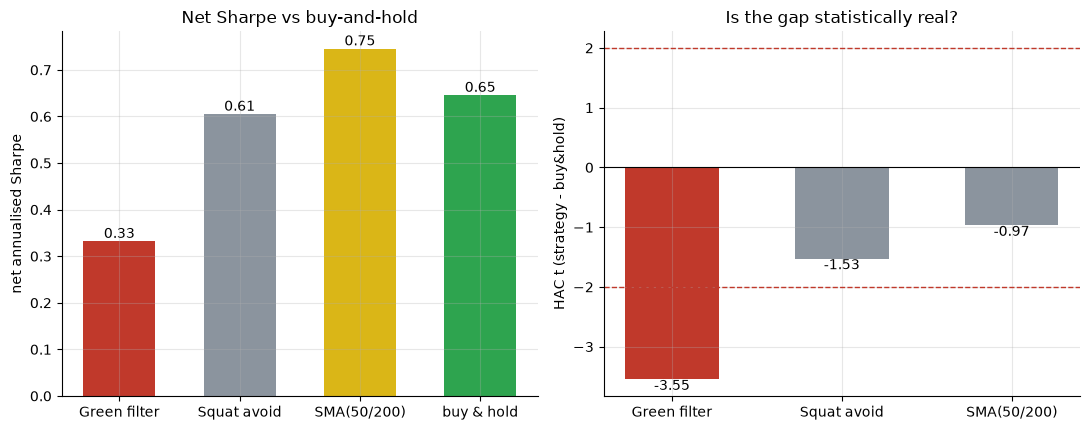

In [4]:
if HAVE_REAL:
    r = st.run_timer(DF, cost_bps=1.0)
    names = ['green', 'squat_avoid', 'sma']
    ss_ = [r[n]['sharpe_strat'] for n in names]
    bh = r['green']['sharpe_bench']
    ts = [r[n]['hac_t_diff'] for n in names]
else:
    names = ['green', 'squat_avoid', 'sma']
    ss_ = [R['timer'][n][0] for n in names]
    bh = R['timer']['green'][1]
    ts = [R['timer'][n][3] for n in names]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.0, 4.4))
labels = ['Green filter', 'Squat avoid', 'SMA(50/200)']
a1.bar(labels + ['buy & hold'], ss_ + [bh], color=[RED, GREY, AMBER, GREEN], width=.6)
for i, v in enumerate(ss_ + [bh]): a1.annotate(f'{v:.2f}', (i, v), ha='center', va='bottom')
a1.set_ylabel('net annualised Sharpe'); a1.set_title('Net Sharpe vs buy-and-hold')
a2.bar(labels, ts, color=[RED if abs(t) >= 2 else GREY for t in ts], width=.55)
for i, t in enumerate(ts): a2.annotate(f'{t:+.2f}', (i, t), ha='center', va='top' if t < 0 else 'bottom')
a2.axhline(-2, ls='--', c=RED, lw=1); a2.axhline(2, ls='--', c=RED, lw=1); a2.axhline(0, c='k', lw=.8)
a2.set_ylabel('HAC t (strategy - buy&hold)'); a2.set_title('Is the gap statistically real?')
plt.tight_layout(); plt.show()

> 💡 In plain words: the Green filter's net Sharpe (**0.33**) is not just below buy-and-hold's (**0.65**) — the gap is **statistically significant** (HAC *t* = **-3.55**), and the cost sweep below shows it isn't a costs story. Squat avoidance (*t* = -1.53) is a wash. The SMA(50/200) crossover — zero volume machinery — posts the best Sharpe of the three (**0.75**).

### 4d · Cost sweep and the sign-permutation placebo

Is the Green filter's underperformance a costs story, or structural?

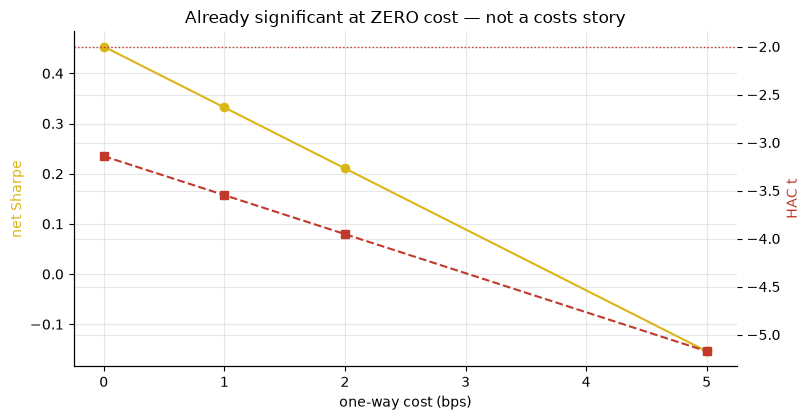

real Sharpe gap -0.314, sign-permutation p = 0.211


In [5]:
if HAVE_REAL:
    sweep = [(cb, st.run_timer(DF, cost_bps=cb)['green']['sharpe_strat'],
              st.run_timer(DF, cost_bps=cb)['green']['hac_t_diff'])
             for cb in (0.0, 1.0, 2.0, 5.0)]
    pv = st.permutation_pvalue_timer(DF, cost_bps=1.0, n_perm=1000)
else:
    sweep = R['cost_sweep']
    pv = {'real_gap': R['perm_gap'], 'p_value': R['perm_p']}
cbs = [x[0] for x in sweep]; shs = [x[1] for x in sweep]; hts = [x[2] for x in sweep]
fig, ax = plt.subplots(figsize=(8.2, 4.3))
ax2 = ax.twinx()
ax.plot(cbs, shs, 'o-', color=AMBER, label='net Sharpe')
ax2.plot(cbs, hts, 's--', color=RED, label='HAC t vs buy-hold')
ax2.axhline(-2, ls=':', c=RED, lw=1)
ax.set_xlabel('one-way cost (bps)'); ax.set_ylabel('net Sharpe', color=AMBER)
ax2.set_ylabel('HAC t', color=RED)
ax.set_title('Already significant at ZERO cost — not a costs story')
plt.tight_layout(); plt.show()
print(f"real Sharpe gap {pv['real_gap']:+.3f}, sign-permutation p = {pv['p_value']:.3f}")

> 💡 In plain words: even at **0 bp** the Green filter is already significantly behind buy-and-hold (*t* = -3.14) — the underperformance is structural (missing most of the tape's drift), costs just make it worse. The sign-permutation placebo puts the real Sharpe gap's unluckiness at *p* = **0.21** — the timer isn't even an unusually bad draw of its own exposure schedule.

### 4e · Faithful-engine & power control — we know the truth here

Synthetic tape: range and volume are two independent AR(1)-in-logs processes (unrelated to the return path), classified into the same four states; a TUNABLE knob plants a Green-continuation / Squat-reversal effect. Null (planted=0) checked over **20 seeds**.

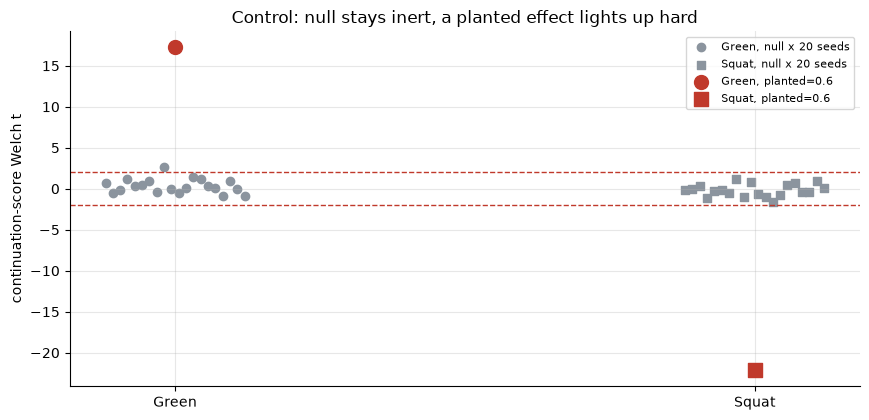

null green: mean t=+0.35 (sd 0.87), |t|>=2 in 1/20
null squat: mean t=-0.17 (sd 0.76), |t|>=2 in 0/20
planted=0.6: green t=+17.23  squat t=-22.14


In [6]:
null_g, null_s = [], []
for s_ in range(20):
    bars, _ = data.synthetic_world(planted=0.0, seed=677 + s_)
    sy = st.synthetic_detect(bars)
    null_g.append(sy['green']['welch_t_cont']); null_s.append(sy['squat']['welch_t_cont'])
null_g = np.asarray(null_g); null_s = np.asarray(null_s)
bars_p, _ = data.synthetic_world(planted=0.6, seed=677)
syp = st.synthetic_detect(bars_p)
planted_g, planted_s = syp['green']['welch_t_cont'], syp['squat']['welch_t_cont']
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.scatter(np.zeros(20) + np.linspace(-.12, .12, 20), null_g, color=GREY, s=36,
           label='Green, null x 20 seeds')
ax.scatter(np.ones(20) + np.linspace(-.12, .12, 20), null_s, color=GREY, s=36, marker='s',
           label='Squat, null x 20 seeds')
ax.scatter([0], [planted_g], color=RED, s=100, zorder=5, label='Green, planted=0.6')
ax.scatter([1], [planted_s], color=RED, s=100, zorder=5, marker='s', label='Squat, planted=0.6')
ax.axhline(-2, ls='--', c=RED, lw=1); ax.axhline(2, ls='--', c=RED, lw=1)
ax.set_xticks([0, 1]); ax.set_xticklabels(['Green', 'Squat'])
ax.set_ylabel('continuation-score Welch t')
ax.set_title('Control: null stays inert, a planted effect lights up hard')
ax.legend(fontsize=8); plt.tight_layout(); plt.show()
print(f'null green: mean t={null_g.mean():+.2f} (sd {null_g.std(ddof=1):.2f}), '
      f'|t|>=2 in {(abs(null_g)>=2).sum()}/20')
print(f'null squat: mean t={null_s.mean():+.2f} (sd {null_s.std(ddof=1):.2f}), '
      f'|t|>=2 in {(abs(null_s)>=2).sum()}/20')
print(f'planted=0.6: green t={planted_g:+.2f}  squat t={planted_s:+.2f}')

> 💡 In plain words: across 20 null worlds the detector averages *t* = +0.35 (Green) / -0.17 (Squat) and almost never crosses the bar (1/20 and 0/20); a modest planted effect reads *t* = +17.23 / -22.14. The harness is unbiased and has the power to find this exact pattern — the real-tape near-zero *t*'s above are the genuine absence of an effect, not a blind detector. *(A faithful-engine / power check only — never cited in support of the real-tape stamp.)*

## 5 · The verdict

- **Signal `NONE`** — Green continuation-score *t* = **-0.85** (SPY), **-0.33** (pooled); Squat *t* = **+0.54** (SPY), **+1.35** (pooled). Both under **t = 2**, both on the wrong side of the claim on the headline tape, placebo *p* = 0.40 / 0.58, and the sign flips ticker-by-ticker with no consistent pattern.
- **Tradability `MIRAGE`** — the Green-filter timer loses to buy-and-hold at HAC *t* = **-3.55** net, still significant at 0 bp cost; a volume-free SMA(50/200) beats it outright.
- **"Green flags continuation, Squat flags reversal"? `BUSTED`** — both predictions fail on the tape, fail the placebo, fail to replicate across six markets, and the one strategy built on the claim's "good" half actively underperforms doing nothing at all.

## 6 · Going further

- **A mechanical confound worth chasing.** BW-MFI is a *ratio* of range to volume — a volume spike mechanically tends to lower MFI even absent any informative price action, which is exactly why Fake and Squat dominate the day-count on every tape here. That skew is baked into the ratio's definition, not a market fact; separating it from any genuine price-volume information is the natural sequel.
- **Fake's incidental pooled crossing** (*t* = −2.07, not part of the pre-registered Green/Squat pair) doesn't survive the per-ticker check — flagged here only so it isn't silently discarded, not promoted to a finding.
- **Dedup map:** [424-ease-of-movement](../../424-ease-of-movement/) (the closest relative — same range/volume ratio, tested continuously, finds a real but SMA-equivalent trend effect), [418-money-flow-index](../../418-money-flow-index/) and [423-force-index](../../423-force-index/) (different volume-oscillator constructions), [676-gator-oscillator](../../676-gator-oscillator/) (same author, a moving-average construct with no volume term).

*The reproducible core is offline and deterministic; frozen numbers live in [`docs/results.md`](../docs/results.md), sources in [`docs/references.md`](../docs/references.md).*